In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample
from scipy.stats import mannwhitneyu
from scipy.stats import wilcoxon

plt.style.use('tableau-colorblind10')
plt.rcParams.update({'font.size': 18, 'font.family':'Arial'})

In [3]:
vmgc  = pd.read_csv('VMGC_rarefaction_pangenome_sizes.csv')
gtdb  = pd.read_csv('GTDB_rarefaction_pangenome_sizes.csv')

vmgc.head()

,species,num_genomes,rep_number,centroid_90,centroid_99
0,240891,10,0,1538,3232
1,240891,10,1,1457,2959
2,240891,10,2,1438,2877
3,240891,10,3,1493,2999
4,240891,10,4,1469,2984


In [4]:
sp_list = gtdb['species'].unique()

In [5]:
sp_list

array([240891, 571325, 611554, 619501, 783244, 988598])

In [6]:

base_dir = '/Users/cdubin/VMGC_cervical_dysplasia_paper/code/'
mapping = pd.read_csv(f'{base_dir}/compare_VMGC_GTDB/MIDAS_VMGC_species_mapping.csv')
vmgc_to_species = mapping.drop_duplicates('VMGC_species_id').set_index('VMGC_species_id')['VMGC_species'].to_dict()
vmgc_to_GTDB = mapping.drop_duplicates('VMGC_species_id').set_index('VMGC_species_id')['MIDAS_species_id'].to_dict()

In [7]:
vmgc_genomes = pd.read_csv(f'{base_dir}/VMGC/VMGC_db_build/genomes.tsv', sep='\t')
vmgc_total_genome_counts = vmgc_genomes.groupby('species')['genome'].nunique().loc[sp_list]
vmgc_total_genome_counts


species
240891    1876
571325     327
611554     202
619501     786
783244     700
988598     856
Name: genome, dtype: int64

In [8]:
gtdb_genomes = pd.read_csv(f'{base_dir}/GTDB/GTDB_genomes_in_MIDAS.tsv', sep='\t')
gtdb_total_genome_counts = gtdb_genomes.groupby('species')['genome'].nunique().loc[[vmgc_to_GTDB[i] for i in sp_list]]
gtdb_total_genome_counts


species
100505     31
100515     29
100460     33
103895      5
100323     49
100122    128
Name: genome, dtype: int64

In [9]:
full_pangenome_sizes = []
for sp in sp_list:
        full_pangenome = pd.read_csv(f'{base_dir}/VMGC/VMGC_db/pangenomes/{sp}/clusters_99_info.tsv', sep='\t')
        full_pangenome_sizes += [[sp, vmgc_total_genome_counts.loc[sp], 0, full_pangenome['centroid_90'].nunique(), full_pangenome['centroid_99'].nunique()]]

full_pangenome_sizes = pd.DataFrame(full_pangenome_sizes, columns=vmgc.columns)
vmgc_counts = pd.concat([vmgc, full_pangenome_sizes])
vmgc_counts

,species,num_genomes,rep_number,centroid_90,centroid_99
0,240891,10,0,1538,3232
1,240891,10,1,1457,2959
2,240891,10,2,1438,2877
3,240891,10,3,1493,2999
4,240891,10,4,1469,2984
...,...,...,...,...,...
1,571325,327,0,3353,4820
2,611554,202,0,5083,10189
3,619501,786,0,6256,99104
4,783244,700,0,6618,55339


In [10]:
full_pangenome_sizes = []
for sp in sp_list:

        m = str(vmgc_to_GTDB[sp]).split('.')[0]
        full_pangenome = pd.read_csv(f'{base_dir}/GTDB/GTDB_db/pangenomes/{m}/clusters_99_info.tsv', sep='\t')
        full_pangenome_sizes += [[sp, gtdb_total_genome_counts.loc[int(m)], 0, full_pangenome['centroid_90'].nunique(), full_pangenome['centroid_99'].nunique()]]

full_pangenome_sizes = pd.DataFrame(full_pangenome_sizes, columns=gtdb.columns)

gtdb_counts = pd.concat([gtdb, full_pangenome_sizes])
gtdb_counts

,species,num_genomes,rep_number,centroid_90,centroid_99
0,240891,10,0,1570,3656
1,240891,10,1,1699,3916
2,240891,10,2,1707,3843
3,240891,10,3,1706,3891
4,240891,10,4,1714,3874
...,...,...,...,...,...
1,571325,29,0,2113,2695
2,611554,33,0,3409,6843
3,619501,5,0,1448,3133
4,783244,49,0,2467,11502


In [11]:
def log_func(x, a, b):
    return a * np.log(x + 1) + b

def power_func(x, a, b):
    return a * (x ** b)

In [12]:
species_order = ['Lactobacillus crispatus',
                                'Lactobacillus iners',
                                'Lactobacillus jensenii',
                                'Lactobacillus gasseri',
                                'Bifidobacterium vaginale',
                                'Fannyhessea vaginae']

sp_code_order= mapping.drop_duplicates('MIDAS_GTDB_species').set_index('MIDAS_GTDB_species').loc[species_order]['VMGC_species_id'].tolist()
sp_code_order                        

[988598, 240891, 571325, 611554, 783244, 619501]

In [13]:
import matplotlib
matplotlib.rcParams["text.usetex"] = False


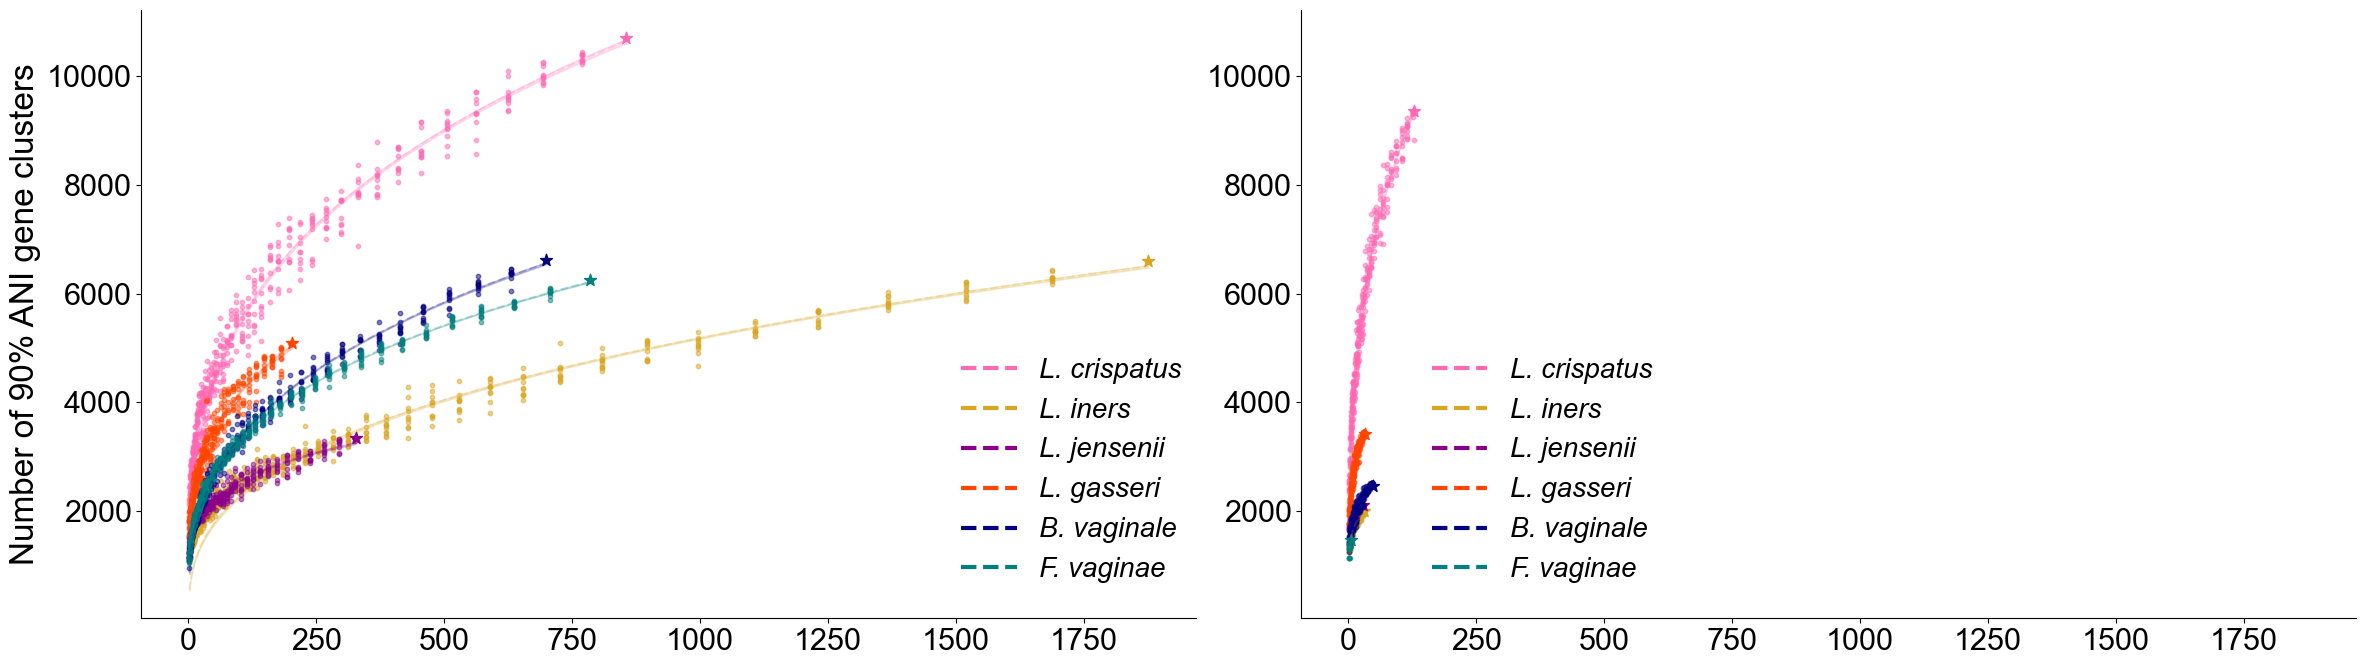

In [14]:

# colors = plt.cm.tab10(np.linspace(0, 1, 10))
fig, axs = plt.subplots(1,2, figsize=(24, 7), )
colors = ['hotpink', 'goldenrod','darkmagenta','orangered',  'navy', 'teal']

for j, counts in enumerate([vmgc_counts, gtdb_counts]):

    ax = axs[j]

    for i, sp in enumerate(sp_code_order):
        
        temp = counts[counts['species'] == sp]
        temp = temp.sort_values('num_genomes')
        x = temp['num_genomes'].values
        y = temp['centroid_90'].values

        # Sort x for plotting fits
        x_sorted = np.linspace(min(x), max(x), 100)

        # Use inverse variance or custom weights
        weights = 1 / (x ** 0.5)

        popt, pcov = curve_fit(power_func, x, y, sigma=weights, absolute_sigma=False)


        # Fit power curve
        # popt, pcov = curve_fit(power_func, x, y, p0=[1, 1])
        a_fit, b_fit = popt
        perr = np.sqrt(np.diag(pcov))
        a_se, b_se = perr

        # Generate smooth x values for plotting the fit
        x_fit = np.linspace(min(x), max(x), 1000)
        y_fit = power_func(x_fit, a_fit, b_fit)

        # Error propagation to compute standard error of the predicted y values
        # dy/da = x^b, dy/db = a * x^b * ln(x)
        J0 = x_fit ** b_fit
        J1 = a_fit * (x_fit ** b_fit) * np.log(x_fit)
        var_y_fit = (J0 ** 2) * pcov[0, 0] + (J1 ** 2) * pcov[1, 1] + 2 * J0 * J1 * pcov[0, 1]
        y_se = np.sqrt(var_y_fit)


        # Compute 95% confidence interval
        # Approximate using error propagation
        # dy/da = x^b, dy/db = a * x^b * ln(x)
        J0 = x_fit ** b_fit  # ∂y/∂a
        J1 = a_fit * (x_fit ** b_fit) * np.log(x_fit)  # ∂y/∂b
        var_y_fit = (J0 ** 2) * pcov[0, 0] + (J1 ** 2) * pcov[1, 1] + 2 * J0 * J1 * pcov[0, 1]
        y_err = 1.96 * np.sqrt(var_y_fit)  # 95% CI (Z = 1.96)

        # Plotting
        xmax_idx = np.argmax(x)
        # color = colors[i % len(colors)]
        label = f'{vmgc_to_species[int(sp)]}'

        label = f"{vmgc_to_species[int(sp)]}"
        label = label.split(' ')[0][0] +'. ' +label.split(' ')[1]
        safe_label = label.replace(" ", r"\ ")

        ax.plot(x_fit, y_fit, label = label, color=colors[i], alpha=0.2, linestyle='--')

        # ax.plot(x_fit, y_fit, label = f"\\textit{label}", )
        # plt.fill_between(x_fit, y_fit - y_se, y_fit + y_se, color=color, alpha=0.3)

        print()
        ax.fill_between(x_fit, y_fit - y_err, y_fit + y_err, color=colors[i], alpha=0.2)


        ax.scatter(x[xmax_idx], y[xmax_idx], color=colors[i], marker='*', s=80)
        ax.scatter(x, y, color=colors[i], marker='o', s=10, alpha=0.5)


    ax.set_xlabel("Number of genomes sampled", fontsize=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axs[0].set_ylabel("Number of 90% ANI gene clusters", fontsize=24)
axs[1].set_xlim(axs[0].get_xlim())
axs[1].set_ylim(axs[0].get_ylim())
axs[0].tick_params(axis='both', which='major', labelsize=22)
axs[1].tick_params(axis='both', which='major', labelsize=22)
# axs[0].set_ylabel("", fontsize=20)
axs[1].set_xlabel("", fontsize=20)
axs[0].set_xlabel("", fontsize=20)


# handles, labels = ax.get_legend_handles_labels()
leg = axs[1].legend(frameon=False, fontsize=20, ncols=1, handlelength=2,
        bbox_to_anchor=(0.1,0.47), 
        columnspacing=1)
for line in leg.get_lines():
    line.set_linewidth(3.0)
    line.set_alpha(1)
for text in leg.get_texts():
    text.set_fontstyle("italic") 

leg = axs[0].legend(frameon=False, fontsize=20, ncols=1, handlelength=2,
        bbox_to_anchor=(1.01,0.47), 
        columnspacing=1)
for line in leg.get_lines():
    line.set_linewidth(3.0)
    line.set_alpha(1)
for text in leg.get_texts():
    text.set_fontstyle("italic") 

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
fig_dir = '/Users/cdubin/VMGC_cervical_dysplasia_paper/figures/'
plt.savefig(f'{fig_dir}/figure_2C-D.png', format='png', dpi=600, bbox_inches="tight")

plt.show()


### Compare curves

In [15]:
def get_tail_slope(df, num_points=5):

    num_genomes = df['num_genomes'].sort_values(ascending=False).unique()
    to_extract = num_genomes[1:num_points+1]
    temp = df[df['num_genomes'].isin(to_extract)]
    model = LinearRegression().fit(temp['num_genomes'].values.reshape(-1, 1), temp['centroid_90'].values)
    return model.coef_[0]  # slope

In [16]:
slopes = {}
for sp in vmgc_counts['species'].unique():

    if sp not in gtdb_counts['species'].values:
        continue

    vmgc_temp = vmgc_counts[vmgc_counts['species']==sp]
    # vmgc_temp['database'] = 'VMGC'
    gtdb_temp = gtdb_counts[gtdb_counts['species']==sp]
    # gtdb_temp['database'] = 'GTDB'

    slopes[vmgc_to_species[sp]] = [get_tail_slope(vmgc_temp), get_tail_slope(gtdb_temp)]

df = pd.DataFrame.from_dict(slopes, columns=['VMGC', 'GTDB'], orient='index')
df['magnitude_diff'] = df['GTDB'] / df['VMGC']
df


,VMGC,GTDB,magnitude_diff
Lactobacillus iners,1.568650,12.783121,8.149123
Lactobacillus jensenii,3.803656,8.474594,2.228013
Lactobacillus gasseri,7.506300,23.518034,3.133106
Fannyhessea vaginae,2.819309,70.950000,25.165738
Bifidobacterium vaginale,4.037261,12.377762,3.065881
Lactobacillus crispatus,4.765950,23.370236,4.903584


In [17]:
wilcoxon(df['VMGC'].values, df['GTDB'].values)

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.03125))